# Wearable Device Dataset from Induced Stress and Structured Exercise Sessions

This Jupyter Notebook presents the recorded data from the Empatica E4 wristband during structured protocols designed to induce stress, and during aerobic and anaerobic exercise sessions. The signals displayed include:

·BVP (Blood Volume Pulse): Adimensional

·TEMP (Skin Temperature): Measured in degrees Celsius [°C] Celsius

·HR (Heart Rate): Measured in beats per minute [bpm]

·EDA (Electrodermal activity): Measured in microsiemens [*μS*]

·ACC (Accelerometer Data): Filtered using a moving average. The accelerometer measures acceleration in the range of [-2g, 2g], with the unit in the ACC.csv file being 1/64g.

The x-axis represents time in seconds.

The graphics representing the protocols are also displayed. The times when participants pressed the wristband button are indicated above the protocol timeline. These correspond to the timestamps in the "tags.csv" file. The protocols are summarized as follows:

- Stress* version 1: 12 tags
- Stress* version 2: 9 tags
- Aerobic version 1: 12 tags
- Aerobic version 2: 8 tags
- Anaerobic version 1: 7 tags
- Anaerobic version 2: 11 tags

**Across the timeline, moments when participants reported their self-perceived stress levels (SL) are indicated in red.*

# Before starting

1) Download the Folder and Files:

Download the folder *'Wearable_Dataset'* and the files *'Stress_Level_v1.csv'* and *'Stress_Level_v2.csv'*.

2) Replace File Paths:

After downloading, ensure you replace the file paths in the Jupyter Notebook with the correct paths on your local PC. This will allow the Notebook to access the data files correctly.

In [1]:
# from google.colab import drive # add if running on Google Colab
# drive.mount('/content/drive')  # add if running on Google Colab

 # Replace the paths
raw_data_folder = "<PATH TO YOUR DATA FOLDER>/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1" # the folder with the raw data

dataset_path="<PATH TO YOUR DATA FOLDER>/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Wearable_Dataset" # the Wearable_Dataset subfolder

stress_level_v1_path= "<PATH TO YOUR DATA FOLDER>/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Stress_Level_v1.csv" # The v1 stress file
stress_level_v2_path= "<PATH TO YOUR DATA FOLDER>/wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1/Stress_Level_v2.csv" # The v2 stress file

3) Install and Import Required Libraries

Before running the Notebook, ensure you have the following Python libraries installed: numpy, pandas, matplotlib, datetime, os. After installing the necessary libraries, import then as follows:


In [2]:
import pandas as pd
import os
import numpy as np
import datetime
import matplotlib.pyplot as plt

## Stress Induction Protocol

### First version (S01 to S18)

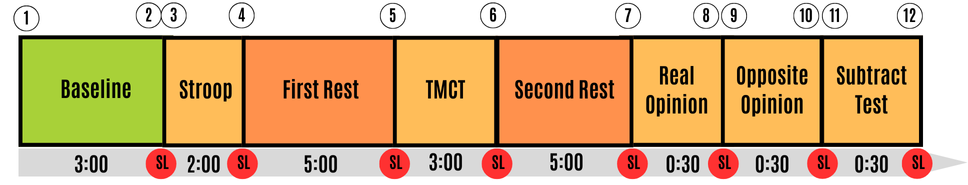

In [ ]:
# from IPython.display import Image, display
# IMG_OUT = "/content/drive/MyDrive/Colab Notebooks/Y2T2/HDAT9800/Group/protocol_images"
# display(Image(f"{IMG_OUT}/stress_v1.png"))

### Second version (f01 to f18)

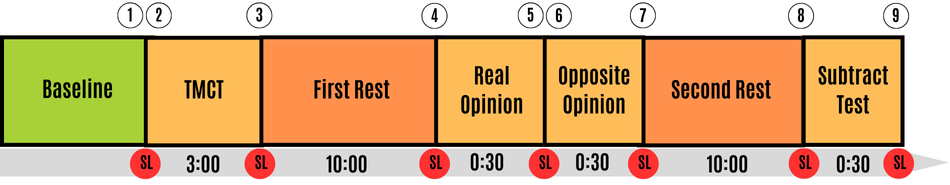

In [ ]:
# display(Image(f"{IMG_OUT}/stress_v2.png"))

## Aerobic Protocol

### First version (S01 to S18)

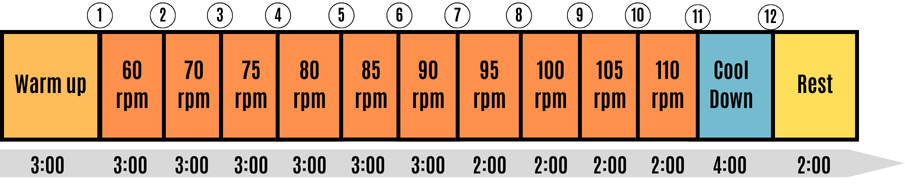

In [ ]:
# display(Image(f"{IMG_OUT}/aerobic_tags_v1.png"))

### Second version (f01 to f13)

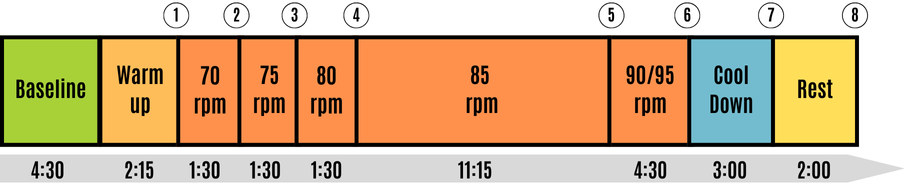

In [ ]:
# display(Image(f"{IMG_OUT}/aerobic_tags_v2.png"))

## Anaerobic Protocol

### First version (S01 to S18)

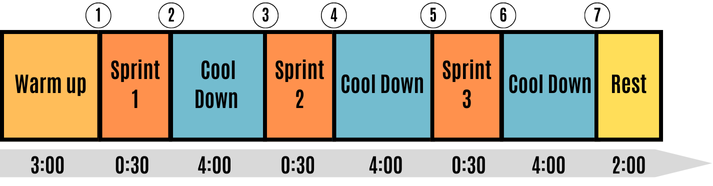

In [ ]:
# display(Image(f"{IMG_OUT}/anaerobic_tags_v1.png"))

### Second version (f01 to f13)

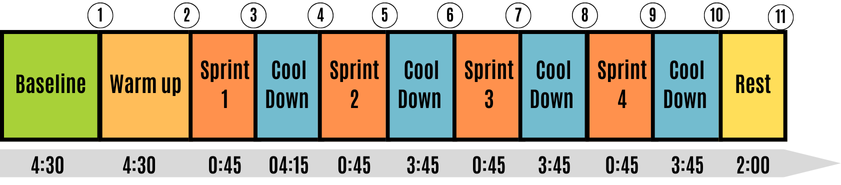

In [ ]:
# display(Image(f"{IMG_OUT}/anaerobic_tags_v2.png"))

# Open and read signals (provided in original data)

## Functions

In [3]:
def moving_average(acc_data):
    # Initialization of variables
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    # Each second (32 samples) the acceleration data is summarized using the following method:
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]

        for j in range(len(buffX)):
            sum_ += max(
                abs(buffX[j] - prevX),
                abs(buffY[j] - prevY),
                abs(buffZ[j] - prevZ)
            )
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        #The output is then filtered:
        avg = avg * 0.9 + (sum_ / 32) * 0.1 #
        results.append(avg)

    return results

In [4]:
def graph_multiple(signals,timeline,subject_signals,state):

    plt.figure(figsize=(25,15))

    keys = list(signals[subject_signals].keys())
    keys.remove("tags")

    i=1

    for key in keys:
        plt.subplot(len(keys),1,i)
        if i==1:
            plt.title(subject_signals + "  -  "+state)
        if key=='ACC':
            acc=moving_average(signals[subject_signals][key])
            plt.plot(acc,label=key)
        else:
            plt.plot(timeline[subject_signals][key],signals[subject_signals][key],label=key)

        for tag in signals[subject_signals]["tags"][1:]:
            plt.axvline(x=tag, color='r', linestyle='-')

        if state=='STRESS' and signals[subject_signals]["tags"]:
            if 'S' in subject_signals: #first version
                plt.axvspan(signals[subject_signals]["tags"][3], signals[subject_signals]["tags"][4], color='red', alpha=0.2) #stroop
                plt.axvspan(signals[subject_signals]["tags"][5], signals[subject_signals]["tags"][6], color='red', alpha=0.2)# tmct
                plt.axvspan(signals[subject_signals]["tags"][7], signals[subject_signals]["tags"][8], color='red', alpha=0.2)#real opinion
                plt.axvspan(signals[subject_signals]["tags"][9], signals[subject_signals]["tags"][10], color='red', alpha=0.2)#opposite opinion
                plt.axvspan(signals[subject_signals]["tags"][11], signals[subject_signals]["tags"][12], color='red', alpha=0.2)#subtract test

            else: #second version
                plt.axvspan(signals[subject_signals]["tags"][2], signals[subject_signals]["tags"][3], color='red', alpha=0.2) #tmct
                plt.axvspan(signals[subject_signals]["tags"][4], signals[subject_signals]["tags"][5], color='red', alpha=0.2)#real opinion
                plt.axvspan(signals[subject_signals]["tags"][6], signals[subject_signals]["tags"][7], color='red', alpha=0.2)#opposite opinion
                plt.axvspan(signals[subject_signals]["tags"][8], signals[subject_signals]["tags"][9], color='red', alpha=0.2)#subtract test

        plt.legend()
        plt.grid()
        i = i+1
    plt.show()

In [6]:
# create a vector from the data frame (signal imported by pandas)
def create_df_array(dataframe):
    matrix_df=dataframe.values
    # returns 2-d matrix
    matrix = np.array(matrix_df)
    array_df = matrix.flatten()# Convert matrix into an array
    return array_df

# convert UTC arrays to arrays in seconds relative to 0 (record beginning)
def time_abs_(UTC_array):
    new_array=[]
    for utc in UTC_array:
        time=(datetime.datetime.strptime(utc,'%Y-%m-%d %H:%M:%S')-datetime.datetime.strptime(UTC_array[0], '%Y-%m-%d %H:%M:%S')).total_seconds()
        new_array.append(int(time))
    return new_array

In [7]:
def read_signals(main_folder):
    signal_dict = {}
    time_dict = {}
    fs_dict = {}

    # Get a list of subfolders in the main folder
    subfolders = next(os.walk(main_folder))[1]

    utc_start_dict={}
    for folder_name in subfolders:
            csv_path = f'{main_folder}/{folder_name}/EDA.csv'
            df=pd.read_csv(csv_path)
            utc_start_dict[folder_name]= df.columns.tolist()

    # Iterate over the subfolders
    for folder_name in subfolders:
        folder_path = os.path.join(main_folder, folder_name)
        # Get a list of files in the subfolder
        files = os.listdir(folder_path)

        # Initialize a dictionary for the signals in the current subfolder
        signals = {}
        time_line = {}
        fs_signal= {}

        # Define the list of desired file names
        desired_files = ['EDA.csv', 'BVP.csv', 'HR.csv', 'TEMP.csv','tags.csv','ACC.csv']

        # Iterate over the files in the subfolder
        for file_name in files:
            file_path = os.path.join(folder_path, file_name)

            # Check if it's a CSV file and if it is in the desired files list
            if file_name.endswith('.csv') and file_name in desired_files:
                # Read the CSV file and store the signal data

                if file_name == 'tags.csv':
                    try:
                        df = pd.read_csv(file_path,header=None)
                        tags_vector = create_df_array(df)
                        tags_UTC_vector =np.insert(tags_vector,0,utc_start_dict[folder_name])
                        signal_array=time_abs_(tags_UTC_vector)
                    except pd.errors.EmptyDataError:
                        signal_array=[]

                else:
                    df = pd.read_csv(file_path)
                    fs = int(df.iloc[0, 0]) # Get sampling frequency
                    #fs= df.loc[0]
                    #fs=int(fs[0])
                    df.drop([0],axis = 0,inplace=True)
                    signal_array = df.values
                    time_array = np.linspace(0, len(signal_array)/fs,len(signal_array))

                signal_name = file_name.split('.')[0]
                signals[signal_name] = signal_array
                time_line[signal_name] = time_array
                fs_signal[signal_name] = fs

        # Store the signals of the current subfolder in the main dictionary
        signal_dict[folder_name] = signals
        time_dict[folder_name] = time_line
        fs_dict[folder_name] = fs_signal

    return signal_dict, time_dict, fs_dict


## Read and save signals

In [8]:
states=os.listdir(dataset_path) #['AEROBIC', 'ANAEROBIC', 'STRESS']

signal_data={}
time_data={}
fs_dict={}
participants={}

for state in states:
    folder_path = f'{dataset_path}/{state}'
    participants[state]=os.listdir(folder_path)
    signal_data[state], time_data[state], fs_dict[state] =read_signals(folder_path) # Returns three dictionaries with subjects info: raw signals (signal_data), temporal data ready to graph (time_data) and sample frequency for escha signal(fs_dict).

# Visualize signals (provided in original data)

## STRESS

In [ ]:
for person in participants['STRESS']:
    graph_multiple(signal_data['STRESS'],time_data['STRESS'],person,'STRESS')

## AEROBIC

In [ ]:
state='AEROBIC'
for person in participants[state]:
    graph_multiple(signal_data[state],time_data[state],person,state)

## ANAEROBIC

In [ ]:
state='ANAEROBIC'
for person in participants[state]:
    graph_multiple(signal_data[state],time_data[state],person,state)

# Working with self reported stress level (provided in original data)

In [12]:
stress_level_v1=pd.read_csv(stress_level_v1_path,index_col=0)
stress_level_v2=pd.read_csv(stress_level_v2_path,index_col=0)

## Stress Level v1

### Stress Level for all participants

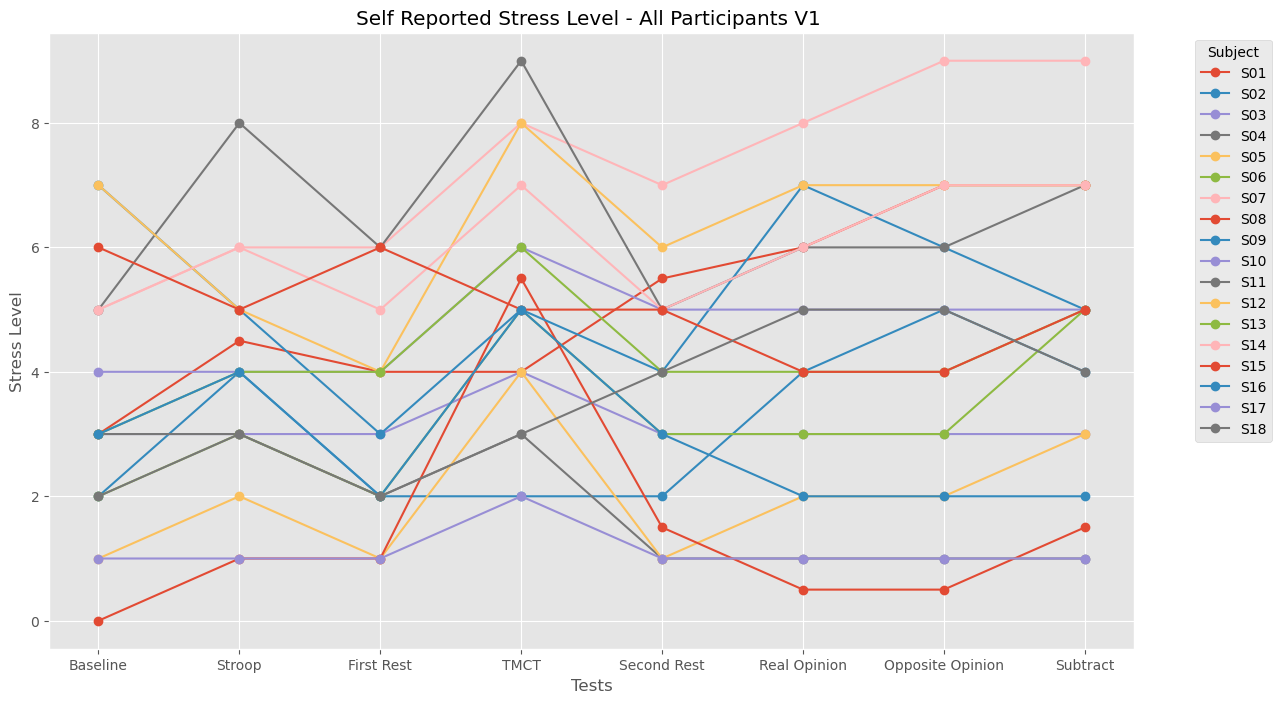

In [13]:
plt.style.use('ggplot')
plt.figure(figsize=(14, 8))

for index, row in stress_level_v1.iterrows():
    plt.plot(stress_level_v1.columns, row, marker='o', label=index)

plt.title('Self Reported Stress Level - All Participants V1 ')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.legend(title='Subject', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Average Stress Level for all participants

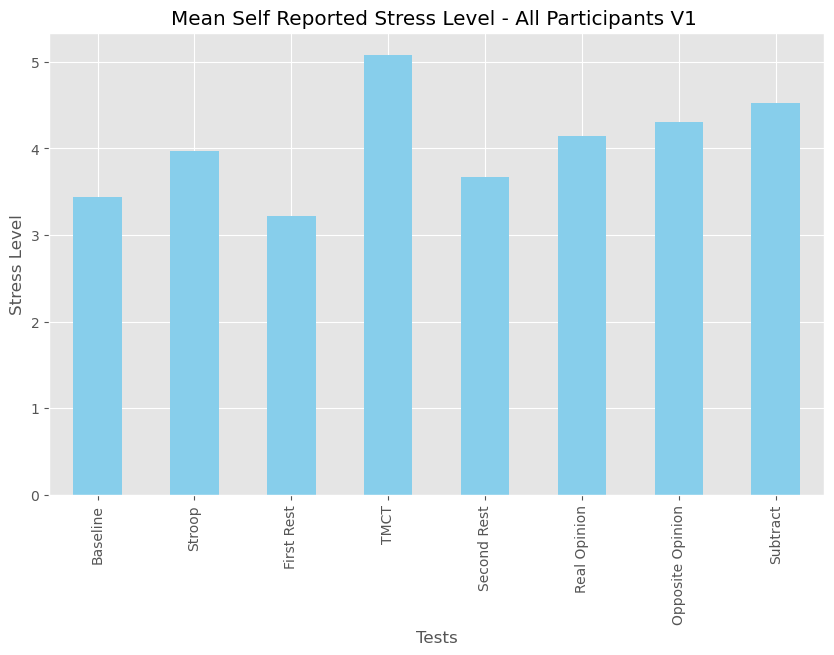

In [14]:
mean_stress_levels = stress_level_v1.mean()

plt.figure(figsize=(10, 6))
mean_stress_levels.plot(kind='bar', color='skyblue')
plt.title('Mean Self Reported Stress Level - All Participants V1 ')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.show()

### Stress Level for one subject

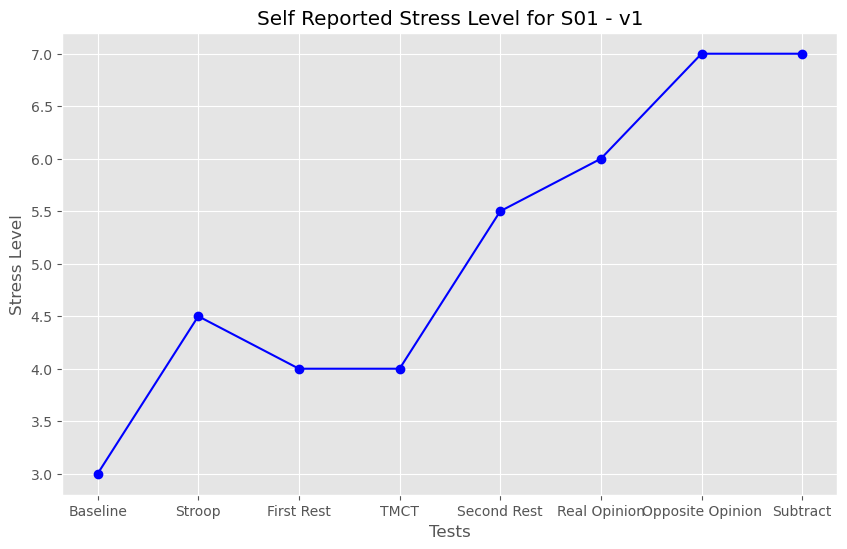

In [15]:
subject = 'S01'  # Replace with subject ID

subject_data = stress_level_v1.loc[subject]

plt.figure(figsize=(10, 6))
plt.plot(subject_data.index, subject_data.values, marker='o', linestyle='-', color='b')

plt.title(f'Self Reported Stress Level for {subject} - v1')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.grid(True)
plt.show()

## Stress Level v2

### Stress Level for all participants

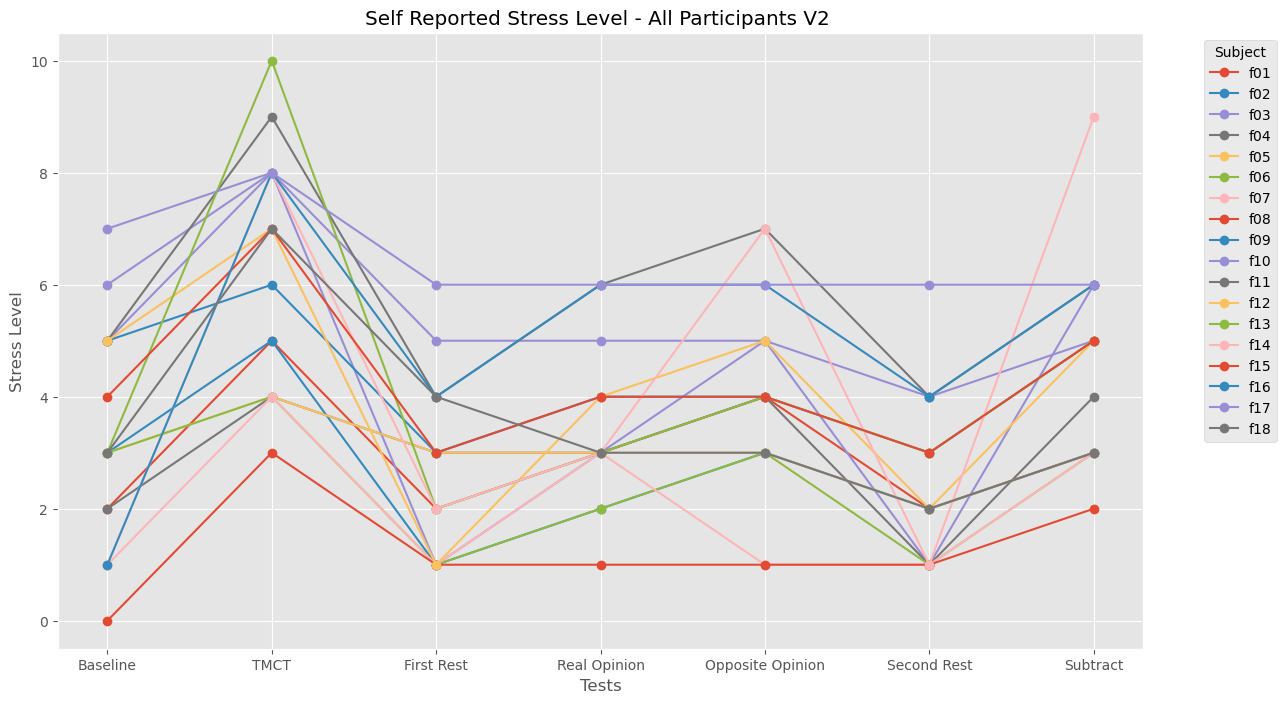

In [16]:
plt.style.use('ggplot')

plt.figure(figsize=(14, 8))

for index, row in stress_level_v2.iterrows():
    plt.plot(stress_level_v2.columns, row, marker='o', label=index)

plt.title('Self Reported Stress Level - All Participants V2 ')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.legend(title='Subject', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Average Stress Level for all participants

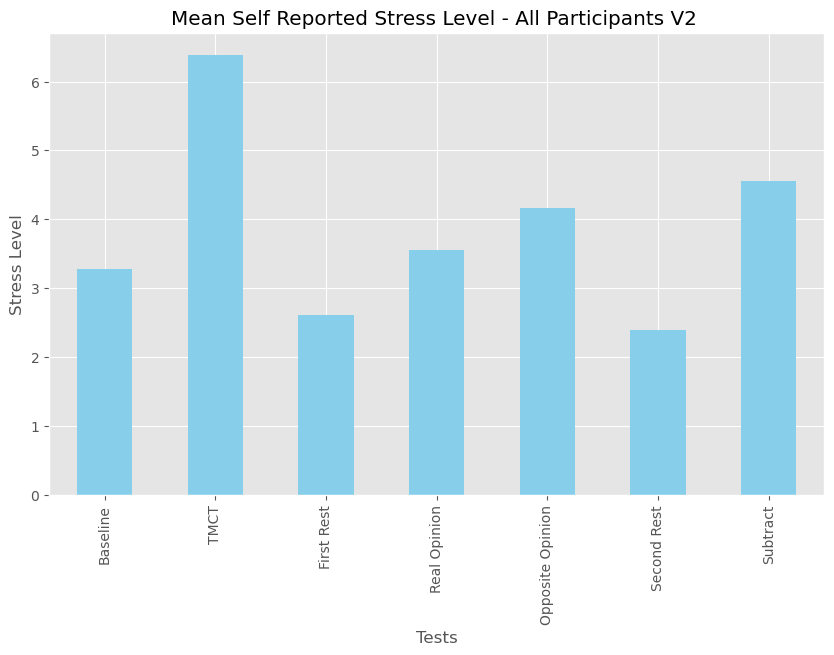

In [17]:

mean_stress_levels = stress_level_v2.mean()

plt.figure(figsize=(10, 6))
mean_stress_levels.plot(kind='bar', color='skyblue')
plt.title('Mean Self Reported Stress Level - All Participants V2 ')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.show()

### Stress Level for one subject

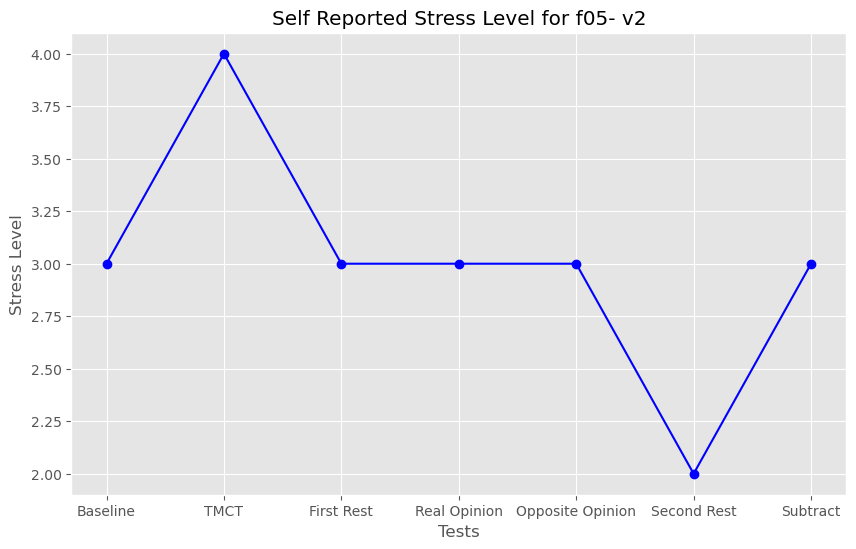

In [18]:
subject = 'f05'  # Replace with dubject ID

subject_data = stress_level_v2.loc[subject]

plt.figure(figsize=(10, 6))
plt.plot(subject_data.index, subject_data.values, marker='o', linestyle='-', color='b')

plt.title(f'Self Reported Stress Level for {subject}- v2')
plt.xlabel('Tests')
plt.ylabel('Stress Level')
plt.grid(True)
plt.show()

## Creating dataset (new code facilitated by Claude Opus 4.8)



In [19]:
# ---- Step 1: flatten the nested dictionaries into a tidy long table ----

# The reader hands us signals buried three levels deep:
#   signal_data[condition][folder][signal] = array of readings
#   time_data[condition][folder][signal]   = matching timestamps

# We want one flat table, one row per reading with the condition / subject / signal as columns
# We walk all three levels, building a small DataFrame for each signal in each session,
# then stack them into one at the end

SIGNALS = ["HR", "EDA"]   # Signals of interest. TEMP, IBI, and raw BVP not used, ACC added below

rows = []   # each signal's block of rows lands here

for condition in signal_data:                # STRESS / AEROBIC / ANAEROBIC
    for folder in signal_data[condition]:    # one folder = one recording session
        # folder name encodes who and which run: "S11_a" -> subject S11, part "a"
        subject = folder.split("_")[0]
        part    = folder.split("_")[1] if "_" in folder else None
        version = "v1" if subject.startswith("S") else "v2"   # S-subjects did v1, f-subjects did v2

        # Each kept signal in this session becomes its own block of rows
        for sig in SIGNALS:
            if sig not in signal_data[condition][folder]:
                continue
            values = np.asarray(signal_data[condition][folder][sig]).flatten()
            times  = np.asarray(time_data[condition][folder][sig]).flatten()
            # The Empatica's HR algorithm needs ~10 s of pulse data before its first
            # estimate, so HR.csv starts 10s after the session. The supplied reader
            # builds every timeline from zero, so 10s offset is added to align HR
            # with the other signals and with the event marks.
            if sig == "HR":
                times = times + 10.0
            n = min(len(values), len(times))   # keep only positions that have both a value and a timestamp
            rows.append(pd.DataFrame({
                "subject": subject, "condition": condition, "part": part,
                "version": version, "signal": sig,
                "t": times[:n], "value": values[:n],
            }))

        # ACC uses the supplied moving_average(), which returns one magnitude per second,
        # so it gets a synthetic 0,1,2,... second timebase rather than raw timestamps.
        # Named ACC_movement to mark it as the derived per-second magnitude
        if "ACC" in signal_data[condition][folder]:
            acc = np.asarray(signal_data[condition][folder]["ACC"])
            mov = moving_average(acc)
            rows.append(pd.DataFrame({
                "subject": subject, "condition": condition, "part": part,
                "version": version, "signal": "ACC_movement",
                "t": np.arange(len(mov), dtype=float), "value": mov,
            }))

# Stack every per-signal block into the single long table
raw_long = pd.concat(rows, ignore_index=True)

print(raw_long.shape)
print(raw_long.head())
print(raw_long.signal.value_counts())

(1252457, 7)
  subject  condition  part version signal          t  value
0     S05  ANAEROBIC  None      v1     HR  10.000000  48.00
1     S05  ANAEROBIC  None      v1     HR  11.000890  57.00
2     S05  ANAEROBIC  None      v1     HR  12.001779  74.33
3     S05  ANAEROBIC  None      v1     HR  13.002669  79.00
4     S05  ANAEROBIC  None      v1     HR  14.003559  79.00
signal
EDA             835530
ACC_movement    208972
HR              207955
Name: count, dtype: int64


In [20]:
# ---- Step 2: resample to a common 1 Hz grid ----
# Signals arrive at different rates (EDA 4 Hz, HR 1 Hz, ACC already 1 Hz).
# Resampling to a shared per-second time base by taking the mean of all readings falling
# within each whole second lets them be compared or overlaid.

signals = (
    raw_long
      # floor each timestamp to its whole second (12.0, 12.25, 12.75 -> 12)
      .assign(t=lambda d: np.floor(d.t).astype(int))
      # group every reading sharing a second and average it, giving one row per signal per second
      # dropna=False so sessions with no 'part' (part is None) aren't silently dropped by the grouping
      .groupby(["subject", "condition", "part", "version", "signal", "t"],
               dropna=False, as_index=False)["value"]
      .mean()
)

print(signals.shape)
print(signals.signal.value_counts())
print(signals.head())

(625886, 7)
signal
ACC_movement    208972
EDA             208959
HR              207955
Name: count, dtype: int64
  subject condition part version        signal  t     value
0     S01   AEROBIC  NaN      v1  ACC_movement  0  0.628125
1     S01   AEROBIC  NaN      v1  ACC_movement  1  1.293438
2     S01   AEROBIC  NaN      v1  ACC_movement  2  1.389094
3     S01   AEROBIC  NaN      v1  ACC_movement  3  1.481434
4     S01   AEROBIC  NaN      v1  ACC_movement  4  1.558291


In [21]:
# ---- Step 3: label protocol phases from the event marks ----
# tags = times when the researcher pressed the wristband button to mark a
# boundary between protocol stages. The supplied reader stores these as seconds
# from session start, with 0 prepended for the start itself, so tag 1 is the
# first actual press.

# PHASE_MAP records which pair of presses brackets each named stage, per
# condition and protocol version, read off the protocol diagrams supplied with
# the dataset and verified against published stage durations.

# each entry is (phase name, tag index where it starts, tag index where it ends)
PHASE_MAP = {
    ("STRESS", "v1"): [
        ("baseline", 1, 2), ("stroop", 3, 4), ("first_rest", 4, 5),
        ("tmct", 5, 6), ("second_rest", 6, 7), ("real_opinion", 7, 8),
        ("opposite_opinion", 9, 10), ("subtract", 11, 12),
    ],
    ("STRESS", "v2"): [
        ("baseline", 1, 2), ("tmct", 2, 3), ("first_rest", 3, 4),
        ("real_opinion", 4, 5), ("opposite_opinion", 6, 7),
        ("second_rest", 7, 8), ("subtract", 8, 9),
    ],
    ("ANAEROBIC", "v1"): [
        ("warm_up", 0, 1), ("sprint_1", 1, 2), ("recovery_1", 2, 3),
        ("sprint_2", 3, 4), ("recovery_2", 4, 5), ("sprint_3", 5, 6),
        ("recovery_3", 6, 7),
    ],
    ("ANAEROBIC", "v2"): [
        ("pre_protocol", 0, 1), ("warm_up", 1, 2), ("sprint_1", 2, 3),
        ("recovery_1", 3, 4), ("sprint_2", 4, 5), ("recovery_2", 5, 6),
        ("sprint_3", 6, 7), ("recovery_3", 7, 8), ("sprint_4", 8, 9),
        ("recovery_4", 9, 10), ("rest", 10, 11),
    ],
    ("AEROBIC", "v1"): [
        ("warm_up", 0, 1), ("rpm_60", 1, 2), ("rpm_70", 2, 3),
        ("rpm_75", 3, 4), ("rpm_80", 4, 5), ("rpm_85", 5, 6),
        ("rpm_90", 6, 7), ("rpm_95", 7, 8), ("rpm_100", 8, 9),
        ("rpm_105", 9, 10), ("rpm_110", 10, 11), ("cool_down", 11, 12),
    ],
    ("AEROBIC", "v2"): [
        ("pre_protocol", 0, 1), ("rpm_70", 1, 2), ("rpm_75", 2, 3),
        ("rpm_80", 3, 4), ("rpm_85", 4, 5), ("rpm_90_95", 5, 6),
        ("cool_down", 6, 7), ("rest", 7, 8),
    ],
}

# Second halves of split recordings: their tag 1 is mid-protocol, not the
# protocol start, so the mapping above does not apply. Excluded from phase
# labelling but retained in the signals table.
NO_PHASE_LABEL = {("S11", "AEROBIC", "b"), ("S16", "ANAEROBIC", "b")}

ev_rows = []
for condition in signal_data:                # STRESS / AEROBIC / ANAEROBIC
    for folder in signal_data[condition]:    # one folder = one recording session
        subject = folder.split("_")[0]
        part    = folder.split("_")[1] if "_" in folder else None
        version = "v1" if subject.startswith("S") else "v2"

        if (subject, condition, part) in NO_PHASE_LABEL:
            continue

        tags = signal_data[condition][folder].get("tags", [])   # button-press times for this session
        # only label a phase if the session actually recorded the button-press that ends it so stages from sessions that stopped early are skipped
        for phase, i0, i1 in PHASE_MAP.get((condition, version), []):
            if i1 < len(tags):
                ev_rows.append({
                    "subject": subject, "condition": condition, "part": part,
                    "version": version, "phase": phase,
                    "t_start": tags[i0], "t_end": tags[i1],
                    "duration": tags[i1] - tags[i0],
                })

events = pd.DataFrame(ev_rows)
print(events.shape)
print(events.groupby(["condition", "version", "phase"]).duration.mean().round(0))

(832, 8)
condition  version  phase           
AEROBIC    v1       cool_down           241.0
                    rpm_100             127.0
                    rpm_105             120.0
                    rpm_110             120.0
                    rpm_60              184.0
                    rpm_70              175.0
                    rpm_75              183.0
                    rpm_80              181.0
                    rpm_85              177.0
                    rpm_90              128.0
                    rpm_95              120.0
                    warm_up             183.0
           v2       cool_down           176.0
                    pre_protocol        786.0
                    rest                118.0
                    rpm_70              120.0
                    rpm_75              109.0
                    rpm_80              117.0
                    rpm_85              727.0
                    rpm_90_95           193.0
ANAEROBIC  v1       recovery_1    

In [22]:
# ---- Step 4: attach phases to signals, assemble supporting tables, save ----

# S02's stress recording restarts a duplicate copy partway through. The duplicate
# begins at row 49,545 of the 32 Hz source (~1548 s); the same instant reproduces
# across the other sample rates. We've chosen to keep only the earlier, unique portion.
S02_CUTOFF = 49545 / 32

signals = signals[~((signals.subject == "S02") &
                    (signals.condition == "STRESS") &
                    (signals.t >= S02_CUTOFF))].copy()

# Tag each second with the phase running then, and t_rel = seconds since that phase
# began.
# t_rel = time since the phase started, so two people who reached the same stage at different points in their session can still be lined up from that stage's start
signals["phase"] = pd.NA
signals["t_rel"] = np.nan

for _, e in events.iterrows():
    # this event's rows: same session, timestamp within [t_start, t_end).
    # when a session has no 'part', match rows where part is missing (otherwise match the exact part)
    m = ((signals.subject == e.subject) &
         (signals.condition == e.condition) &
         (signals.part.isna() if pd.isna(e.part) else signals.part == e.part) &
         (signals.t >= e.t_start) & (signals.t < e.t_end))
    signals.loc[m, "phase"] = e.phase
    signals.loc[m, "t_rel"] = signals.loc[m, "t"] - e.t_start

# --- participants: one row per subject x condition, with demographics ---
# subject-info.csv holds demographics; latin1 because the source files carry non-UTF-8 bytes
info = pd.read_csv(os.path.join(raw_data_folder, "subject-info.csv"), encoding="latin1")
info.columns = [c.strip() for c in info.columns]   # trim stray header whitespace

key = signals[["subject", "condition", "version"]].drop_duplicates()
# info's first column is the subject id, so join on it
participants = key.merge(info, how="left", left_on="subject", right_on=info.columns[0])

# --- self-report: reshape wide (subject x stage) to long so it joins to the physiology ---
sr = []
for v, f in [("v1","Stress_Level_v1.csv"), ("v2","Stress_Level_v2.csv")]:
    df = pd.read_csv(os.path.join(raw_data_folder, f), index_col=0, encoding="latin1")
    df.index.name = "subject"
    long = df.reset_index().melt(id_vars="subject", var_name="phase_label", value_name="rating")
    long["version"] = v
    sr.append(long)
self_report = pd.concat(sr, ignore_index=True)

# self-report arrives with display-name stage headers ("First Rest")
# We map them to the pipeline's phase names so ratings join to signals on a shared key
PHASE_LABEL_MAP = {
    "Baseline": "baseline", "Stroop": "stroop", "First Rest": "first_rest",
    "TMCT": "tmct", "Second Rest": "second_rest", "Real Opinion": "real_opinion",
    "Opposite Opinion": "opposite_opinion", "Subtract": "subtract",
}
self_report["phase"] = self_report.phase_label.str.strip().map(PHASE_LABEL_MAP)

# --- save the four tables ---
OUT = os.path.join(os.path.dirname(raw_data_folder), "built")
os.makedirs(OUT, exist_ok=True)
for name, df in [("participants", participants), ("events", events),
                 ("self_report", self_report), ("signals_1hz", signals)]:
    df.to_parquet(os.path.join(OUT, f"{name}.parquet"), index=False)

print("saved to", OUT)
print(f"participants {participants.shape}  events {events.shape}  "
      f"self_report {self_report.shape}  signals {signals.shape}")
print("phase coverage:", round(signals.phase.notna().mean(), 3))
print(participants.isna().sum())

saved to <data folder>/built
participants (97, 13)  events (832, 8)  self_report (270, 5)  signals (621251, 9)
phase coverage: 0.792
subject                              0
condition                            0
version                              0
Info                                 0
Gender                               0
Age                                  0
Height (cm)                          0
Weight (kg)                          0
Does physical activity regularly?    0
Protocol                             0
Stress Inducement                    0
Aerobic Exercise                     0
Anaerobic Exercise                   0
dtype: int64
